<a href="https://colab.research.google.com/github/deboleenadebroy/Smart-Spam-Classification-System/blob/p1-preprocessing/notebooks/spam_classification_ost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Smart Spam Classification System
# Commit 3: Load and inspect the dataset

import pandas as pd
import numpy as np

print("Libraries imported successfully.")

Libraries imported successfully.


# Smart Spam Classification System

## Dataset Loading and Inspection

This notebook develops a machine-learning based spam classification system.
The first stage loads and examines the dataset before preprocessing and model training.

In [2]:
# Load the SMS Spam Collection dataset

url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

df = pd.read_csv(
    url,
    sep="\t",
    header=None,
    names=["label", "message"]
)

print("Dataset loaded successfully.")
print(f"Number of records: {len(df)}")
print(f"Number of columns: {len(df.columns)}")

df.head()

Dataset loaded successfully.
Number of records: 5572
Number of columns: 2


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Basic dataset inspection

print("Dataset information:")
df.info()

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nMissing values:")
print(df.isnull().sum())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Missing values:
label      0
message    0
dtype: int64


In [4]:
# Check for duplicate messages

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 403


In [5]:
# Commit 4: Text preprocessing

import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

print("Text preprocessing function created.")

Text preprocessing function created.


In [6]:
# Commit 5: TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer with English stop-word removal and max features
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

print("TF-IDF vectorizer initialized successfully.")

TF-IDF vectorizer initialized successfully.


In [7]:
# Commit 6: Train-Test Split

from sklearn.model_selection import train_test_split

# Apply text preprocessing to create the cleaned text feature column
df['clean_message'] = df['message'].apply(clean_text)

# Feature and target variables
X = df['clean_message']
y = df['label']

# Split dataset with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training sample count: {len(X_train)}")
print(f"Testing sample count: {len(X_test)}")
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTesting class distribution:")
print(y_test.value_counts())

Training sample count: 4457
Testing sample count: 1115

Training class distribution:
label
ham     3859
spam     598
Name: count, dtype: int64

Testing class distribution:
label
ham     966
spam    149
Name: count, dtype: int64


# Commit 7: TF-IDF Feature Transformation

- TF-IDF converts the cleaned text messages into numerical feature vectors.
- The vectorizer is fitted only on the training data.
- The test data is transformed using the vocabulary learned from the training data.
- This prevents information from the test set leaking into the training process.

In [8]:
# Commit 7: TF-IDF Feature Transformation

from sklearn.feature_extraction.text import TfidfVectorizer

# Use the existing vectorizer configuration
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

# Fit ONLY on training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data using the fitted vectorizer
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)
print("Number of TF-IDF features:", len(vectorizer.get_feature_names_out()))

Training TF-IDF shape: (4457, 5000)
Testing TF-IDF shape: (1115, 5000)
Number of TF-IDF features: 5000


# Commit 8: Logistic Regression Classifier

Train a baseline Logistic Regression model using TF-IDF features and generate predictions on the test set.

In [9]:
# Commit 8: Logistic Regression Classifier

from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_tfidf, y_train)

# Generate predictions on test data
y_pred = model.predict(X_test_tfidf)

# Display training and prediction summary
print("Logistic Regression model trained successfully.")
print(f"Number of training samples: {X_train_tfidf.shape[0]}")
print(f"Number of test predictions: {len(y_pred)}")
print("\nPredicted class distribution:")
print(pd.Series(y_pred).value_counts())

Logistic Regression model trained successfully.
Number of training samples: 4457
Number of test predictions: 1115

Predicted class distribution:
ham     1005
spam     110
Name: count, dtype: int64


# Commit 9: Model Evaluation

Evaluate the performance of the trained Logistic Regression model on the test dataset using standard classification metrics, a detailed classification report, and a confusion matrix visualization.

=== Model Evaluation Metrics ===
Accuracy:  0.9650
Precision: 1.0000
Recall:    0.7383
F1-Score:  0.8494

=== Classification Report ===
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.91      1115
weighted avg       0.97      0.97      0.96      1115

=== Confusion Matrix ===
[[966   0]
 [ 39 110]]


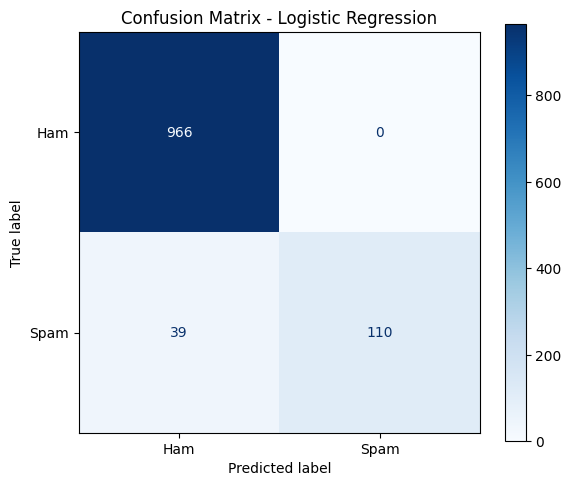

In [10]:
# Commit 9: Model Evaluation

import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Calculate evaluation metrics (with 'spam' as the positive class)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='spam')
recall = recall_score(y_test, y_pred, pos_label='spam')
f1 = f1_score(y_test, y_pred, pos_label='spam')

print("=== Model Evaluation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Print classification report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])
print("=== Confusion Matrix ===")
print(cm)

# Display confusion matrix visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()